<a href="https://colab.research.google.com/github/SaiguruNagula/Industrial_Defect_dectition_Using_DeepLearning/blob/main/DL_MINI_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 Deep Learning-Based Automated Visual Inspection
## Hybrid CNN + Vision Transformer — Complete Colab Pipeline


>

---
## CELL 1 — Install packages & set up project

In [ ]:
!pip install torch torchvision scikit-learn matplotlib pillow tqdm -q

import os, sys, json, math, random, time, warnings
import numpy as np
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import torchvision.transforms as T
from torchvision.models import resnet50, ResNet50_Weights
from PIL import Image, ImageDraw, ImageFilter
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    classification_report
)
from IPython.display import Image as IPImage, display
from collections import defaultdict
from pathlib import Path
from typing import Optional, List, Tuple, Dict
from torch.cuda.amp import GradScaler, autocast

torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs('outputs/xai', exist_ok=True)

print(f'✓ PyTorch  : {torch.__version__}')
print(f'✓ Device   : {DEVICE}')
if torch.cuda.is_available():
    print(f'✓ GPU      : {torch.cuda.get_device_name(0)}')
print('✓ All imports successful')

✓ PyTorch  : 2.10.0+cu128
✓ Device   : cuda
✓ GPU      : Tesla T4
✓ All imports successful


---
## CELL 2 — Mount Google Drive & extract datasets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tarfile, os

# Create extraction folders
os.makedirs('/content/data/mvtec', exist_ok=True)

DRIVE_FOLDER = '/content/drive/MyDrive'  # ✓ correct — files are in root

BOTTLE_PATH = f'{DRIVE_FOLDER}/bottle.tar.xz'
GRID_PATH   = f'{DRIVE_FOLDER}/grid.tar.xz'

# Extract Bottle
if os.path.exists(BOTTLE_PATH):
    print('Extracting bottle.tar.xz ...')
    with tarfile.open(BOTTLE_PATH) as f:
        f.extractall('/content/data/mvtec')
    print('  ✓ Bottle extracted')

# Extract Grid
if os.path.exists(GRID_PATH):
    print('Extracting grid.tar.xz ...')
    with tarfile.open(GRID_PATH) as f:
        f.extractall('/content/data/mvtec')
    print('  ✓ Grid extracted')

Mounted at /content/drive
Extracting bottle.tar.xz ...
  ✓ Bottle extracted
Extracting grid.tar.xz ...
  ✓ Grid extracted


---
## CELL 3 — Model Architecture (Hybrid CNN + Transformer)

In [ ]:
# ============================================================
# CNN BACKBONE WITH FEATURE PYRAMID NETWORK
# ============================================================
class CNNBackbone(nn.Module):
    def __init__(self, pretrained=True, freeze_layers=2):
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        resnet  = resnet50(weights=weights)
        self.stem   = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4
        for layer in [self.stem, self.layer1, self.layer2][:freeze_layers]:
            for p in layer.parameters(): p.requires_grad = False
        self.fpn_lat2 = nn.Conv2d(512,  256, 1)
        self.fpn_lat3 = nn.Conv2d(1024, 256, 1)
        self.fpn_lat4 = nn.Conv2d(2048, 256, 1)
        self.fpn_out2 = nn.Conv2d(256, 256, 3, padding=1)
        self.fpn_out3 = nn.Conv2d(256, 256, 3, padding=1)
        self.fpn_out4 = nn.Conv2d(256, 256, 3, padding=1)

    def forward(self, x):
        x  = self.stem(x)
        c2 = self.layer2(self.layer1(x))
        c3 = self.layer3(c2)
        c4 = self.layer4(c3)
        p4 = self.fpn_lat4(c4)
        p3 = self.fpn_lat3(c3) + F.interpolate(p4, size=c3.shape[-2:], mode='nearest')
        p2 = self.fpn_lat2(c2) + F.interpolate(p3, size=c2.shape[-2:], mode='nearest')
        return self.fpn_out2(p2), self.fpn_out3(p3), self.fpn_out4(p4)

# ============================================================
# 2D POSITIONAL ENCODING
# ============================================================
class PositionalEncoding2D(nn.Module):
    def __init__(self, d_model, max_h=64, max_w=64):
        super().__init__()

        if d_model % 4 != 0:
            raise ValueError("d_model must be divisible by 4")

        pe = torch.zeros(d_model, max_h, max_w)

        d_half = d_model // 2
        d_quarter = d_model // 4

        div_term = torch.exp(
            torch.arange(0, d_quarter).float() * (-math.log(10000.0) / d_quarter)
        )

        pos_h = torch.arange(max_h).float().unsqueeze(1)  # (H,1)
        pos_w = torch.arange(max_w).float().unsqueeze(0)  # (1,W)

        # Height encoding
        for i in range(d_quarter):
            pe[2*i, :, :] = torch.sin(pos_h * div_term[i]).repeat(1, max_w)
            pe[2*i+1, :, :] = torch.cos(pos_h * div_term[i]).repeat(1, max_w)

        # Width encoding
        for i in range(d_quarter):
            pe[d_half + 2*i, :, :] = torch.sin(pos_w * div_term[i]).repeat(max_h, 1)
            pe[d_half + 2*i + 1, :, :] = torch.cos(pos_w * div_term[i]).repeat(max_h, 1)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :, :x.shape[-2], :x.shape[-1]]

# ============================================================
# TRANSFORMER ATTENTION BLOCK
# ============================================================
class TransformerAttentionBlock(nn.Module):
    def __init__(self, d_model=256, nhead=8, dim_feedforward=1024, dropout=0.1, num_layers=3):
        super().__init__()
        self.pos_enc = PositionalEncoding2D(d_model)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward, dropout=dropout,
            batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)

    def forward(self, x):
        B, C, H, W = x.shape
        x = self.pos_enc(x)
        tokens = x.flatten(2).permute(0, 2, 1)
        out = self.transformer(tokens)
        return out.permute(0, 2, 1).reshape(B, C, H, W)

# ============================================================
# GRADIENT REVERSAL (DOMAIN ADAPTATION)
# ============================================================
class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)
    @staticmethod
    def backward(ctx, grad):
        return grad.neg() * ctx.alpha, None

class DomainAdaptationModule(nn.Module):
    def __init__(self, in_features=256, alpha=1.0):
        super().__init__()
        self.alpha = alpha
        self.disc  = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(in_features, 128), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU(inplace=True), nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.disc(GradReverse.apply(x, self.alpha))

# ============================================================
# DETECTION HEAD
# ============================================================
class DefectDetectionHead(nn.Module):
    def __init__(self, in_channels=256, num_classes=2):
        super().__init__()
        def tower():
            layers = []
            for _ in range(4):
                layers += [nn.Conv2d(in_channels, in_channels, 3, padding=1),
                           nn.GroupNorm(32, in_channels), nn.ReLU(inplace=True)]
            return nn.Sequential(*layers)
        self.cls_tower = tower()
        self.global_cls = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(in_channels, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.5), nn.Linear(256, num_classes)
        )
        nn.init.constant_(self.global_cls[-1].bias, -math.log((1-0.01)/0.01))

    def forward(self, features):
        return self.global_cls(self.cls_tower(features[0]))

# ============================================================
# FULL HYBRID MODEL
# ============================================================
class HybridAVIModel(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()
        self.backbone  = CNNBackbone(pretrained=pretrained, freeze_layers=2)
        self.attn_p4   = TransformerAttentionBlock(256, nhead=8, num_layers=3)
        self.attn_p3   = TransformerAttentionBlock(256, nhead=8, num_layers=2)
        self.det_head  = DefectDetectionHead(256, num_classes)
        self.da_module = DomainAdaptationModule(256)
        self._activations = None
        self._gradients   = None

    def save_grad(self, grad): self._gradients = grad

    def forward(self, x):
        p2, p3, p4   = self.backbone(x)
        p4_attn      = self.attn_p4(p4)
        p3_attn      = self.attn_p3(p3)
        if p4_attn.requires_grad:
            p4_attn.register_hook(self.save_grad)
        self._activations = p4_attn
        logits       = self.det_head([p2, p3_attn, p4_attn])
        domain_logits = self.da_module(p4_attn) if self.training else None
        return logits, domain_logits

# Build model
model = HybridAVIModel(num_classes=2, pretrained=True).to(DEVICE)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✓ Model built')
print(f'  Total params     : {total:,}')
print(f'  Trainable params : {trainable:,}')

# Quick forward pass test
model.eval()
with torch.no_grad():
    _out, _ = model(torch.randn(2, 3, 224, 224).to(DEVICE))
print(f'  Forward pass ✓   output shape: {_out.shape}')

✓ Model built
  Total params     : 32,615,300
  Trainable params : 32,389,956
  Forward pass ✓   output shape: torch.Size([2, 2])


---
## CELL 4 — Datasets

In [ ]:
# ============================================================
# AUGMENTATION
# ============================================================
def get_transform(mode='train', image_size=224):
    if mode == 'train':
        return T.Compose([
            T.RandomResizedCrop(image_size, scale=(0.7, 1.0)),
            T.RandomHorizontalFlip(0.5),
            T.RandomVerticalFlip(0.3),
            T.RandomRotation(15),
            T.ColorJitter(0.3, 0.3, 0.2, 0.05),
            T.GaussianBlur(3, sigma=(0.1, 1.5)),
            T.ToTensor(),
            T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])
    return T.Compose([
        T.Resize((image_size, image_size)),
        T.CenterCrop(image_size),
        T.ToTensor(),
        T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])

# ============================================================
# SYNTHETIC DATASET (always available fallback)
# ============================================================
def make_synthetic_img(image_size=224):
    label = random.randint(0, 1)
    img   = Image.new('RGB', (image_size, image_size))
    draw  = ImageDraw.Draw(img)
    bg    = tuple(random.randint(80, 200) for _ in range(3))
    draw.rectangle([0,0,image_size,image_size], fill=bg)
    arr   = np.array(img).astype(np.int16)
    arr  += np.random.randint(-20, 20, arr.shape, dtype=np.int16)
    img   = Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))
    draw  = ImageDraw.Draw(img)
    if label == 1:
        dt = random.randint(0, 3)
        if dt == 0:  # scratch
            draw.line([(random.randint(20,80), random.randint(20,80)),
                       (random.randint(140,200), random.randint(140,200))],
                      fill=tuple(random.randint(10,50) for _ in range(3)), width=random.randint(1,4))
        elif dt == 1:  # pit
            cx,cy,r = random.randint(50,174), random.randint(50,174), random.randint(5,20)
            draw.ellipse([cx-r,cy-r,cx+r,cy+r], fill=tuple(random.randint(10,60) for _ in range(3)))
        elif dt == 2:  # stain
            cx,cy = random.randint(40,184), random.randint(40,184)
            draw.ellipse([cx-20,cy-20,cx+20,cy+20], fill=tuple(random.randint(150,255) for _ in range(3)))
        else:  # scale
            x,y = random.randint(10,150), random.randint(10,200)
            draw.rectangle([x,y,x+random.randint(40,80),y+random.randint(5,15)],
                           fill=tuple(random.randint(30,80) for _ in range(3)))
    img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0, 0.8)))
    return img, label

class SyntheticDataset(Dataset):
    def __init__(self, n=500, mode='train', seed=42):
        random.seed(seed); np.random.seed(seed)
        self.n = n; self.transform = get_transform(mode)
    def __len__(self): return self.n
    def __getitem__(self, idx):
        img, label = make_synthetic_img()
        return {'image': self.transform(img), 'label': torch.tensor(label, dtype=torch.long)}

# ============================================================
# MVTEC AD DATASET
# ============================================================
class MVTecDataset(Dataset):
    def __init__(self, root, category='bottle', split='train'):
        self.transform = get_transform(split)
        self.samples   = []
        cat_dir = Path(root) / category / split
        if not cat_dir.exists():
            print(f'  MVTec {category}/{split} not found — using synthetic')
            self._synthetic = True; self._n = 300 if split=='train' else 100
            return
        self._synthetic = False
        for defect_dir in sorted(cat_dir.iterdir()):
            label = 0 if defect_dir.name == 'good' else 1
            for img_path in sorted(defect_dir.glob('*.png')):
                self.samples.append((img_path, label))
        random.shuffle(self.samples)
        print(f'  MVTec {category}/{split}: {len(self.samples)} images')

    def __len__(self):
        return len(self.samples) if not self._synthetic else self._n

    def __getitem__(self, idx):
        if self._synthetic:
            img, label = make_synthetic_img()
        else:
            path, label = self.samples[idx]
            img = Image.open(path).convert('RGB')
        return {'image': self.transform(img), 'label': torch.tensor(label, dtype=torch.long)}

# ============================================================
# NEU-DET DATASET
# ============================================================
NEU_CLASSES = {'Cr':0,'In':1,'Pa':2,'PS':3,'RS':4,'Sc':5}

class NEUDataset(Dataset):
    def __init__(self, root, split='train', train_ratio=0.8):
        # Map 6 NEU classes → binary (good=0 doesn't exist in NEU, all are defects=1)
        # So we use: 3 classes (Cr,In,Pa) = label 0, rest = label 1 for binary
        # OR use all 6 as-is for multi-class. Here we do binary.
        self.transform = get_transform(split)
        self._synthetic = False
        img_dir = Path(root) / 'IMAGES'
        if not img_dir.exists():
            # Try common alternate structures
            for alt in [Path(root), Path(root)/'images', Path(root)/'train']:
                jpgs = list(alt.glob('**/*.jpg')) if alt.exists() else []
                if jpgs:
                    img_dir = alt; break
            else:
                print(f'  NEU-DET not found — using synthetic')
                self._synthetic = True; self._n = 400 if split=='train' else 100
                return
        all_imgs = sorted(img_dir.glob('*.jpg')) + sorted(img_dir.glob('**/*.jpg'))
        all_imgs = list(set(all_imgs))  # deduplicate
        split_idx = int(len(all_imgs) * train_ratio)
        self.samples = all_imgs[:split_idx] if split=='train' else all_imgs[split_idx:]
        print(f'  NEU-DET {split}: {len(self.samples)} images')

    def _get_label(self, path):
        prefix = path.stem[:2]
        # Binary: group first 3 classes as 0, last 3 as 1
        return 0 if NEU_CLASSES.get(prefix, 0) < 3 else 1

    def __len__(self):
        return len(self.samples) if not self._synthetic else self._n

    def __getitem__(self, idx):
        if self._synthetic:
            img, label = make_synthetic_img()
        else:
            path  = self.samples[idx]
            img   = Image.open(path).convert('RGB')
            label = self._get_label(path)
        return {'image': self.transform(img), 'label': torch.tensor(label, dtype=torch.long)}

# ============================================================
# BUILD DATALOADERS
# ============================================================
MVTEC_ROOT = '/content/data/mvtec'
NEU_ROOT   = None   # no NEU-DET, will use synthetic automatically

def collate(batch):
    return {
        'image': torch.stack([b['image'] for b in batch]),
        'label': torch.stack([b['label'] for b in batch])
    }

print('Building datasets...')
train_ds = ConcatDataset([
    MVTecDataset(MVTEC_ROOT, 'bottle', 'train'),
    MVTecDataset(MVTEC_ROOT, 'grid',   'train'),
    SyntheticDataset(500, 'train')       # ← removed NEU line
])
val_ds = ConcatDataset([
    MVTecDataset(MVTEC_ROOT, 'bottle', 'test'),
    MVTecDataset(MVTEC_ROOT, 'grid',   'test'),
    SyntheticDataset(150, 'val', seed=99)  # ← removed NEU line
])

BATCH_SIZE   = 32
NUM_WORKERS  = 2
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          drop_last=True, collate_fn=collate)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          collate_fn=collate)

print(f'\n✓ Train samples : {len(train_ds)}')
print(f'✓ Val samples   : {len(val_ds)}')
print(f'✓ Train batches : {len(train_loader)}')
print(f'✓ Val batches   : {len(val_loader)}')

# Sanity check
batch = next(iter(train_loader))
print(f'✓ Batch image   : {batch["image"].shape}')
print(f'✓ Batch labels  : {batch["label"].unique()}')

Building datasets...
  MVTec bottle/train: 209 images
  MVTec grid/train: 264 images
  MVTec bottle/test: 83 images
  MVTec grid/test: 78 images

✓ Train samples : 973
✓ Val samples   : 311
✓ Train batches : 30
✓ Val batches   : 10
✓ Batch image   : torch.Size([32, 3, 224, 224])
✓ Batch labels  : tensor([0, 1])


---
## CELL 5 — Loss, Optimizer, Scheduler

In [ ]:
# ============================================================
# FOCAL LOSS
# ============================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce   = F.cross_entropy(inputs, targets, reduction='none')
        pt   = torch.exp(-ce)
        at   = torch.where(targets==1,
                           torch.tensor(self.alpha, device=inputs.device),
                           torch.tensor(1-self.alpha, device=inputs.device))
        return (at * (1-pt)**self.gamma * ce).mean()

# ============================================================
# COSINE WARMUP SCHEDULER
# ============================================================
class CosineWarmupScheduler(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, warmup_steps, total_steps, min_lr=0.01, last_epoch=-1):
        self.warmup  = warmup_steps
        self.total   = total_steps
        self.min_lr  = min_lr
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        s = self.last_epoch
        if s < self.warmup:
            f = s / max(1, self.warmup)
        else:
            p = (s - self.warmup) / max(1, self.total - self.warmup)
            f = self.min_lr + 0.5*(1-self.min_lr)*(1+math.cos(math.pi*p))
        return [b*f for b in self.base_lrs]

# ============================================================
# SETUP
# ============================================================
EPOCHS       = 30       # ← Change to 50 for full quality submission
LR           = 1e-4
WEIGHT_DECAY = 1e-4
WARMUP_EP    = 3
PATIENCE     = 8

criterion = FocalLoss(alpha=0.25, gamma=2.0)
da_loss   = nn.CrossEntropyLoss()

# Differential LR — lower for frozen backbone
backbone_params = list(model.backbone.parameters())
other_params    = [p for n,p in model.named_parameters() if 'backbone' not in n]
optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': LR * 0.1},
    {'params': other_params,    'lr': LR}
], weight_decay=WEIGHT_DECAY)

total_steps  = EPOCHS * len(train_loader)
warmup_steps = WARMUP_EP * len(train_loader)
scheduler    = CosineWarmupScheduler(optimizer, warmup_steps, total_steps)
scaler       = GradScaler() if torch.cuda.is_available() else None

print(f'✓ Focal Loss   : α=0.25, γ=2.0')
print(f'✓ Optimizer    : AdamW, lr={LR}')
print(f'✓ Scheduler    : CosineWarmup ({WARMUP_EP} warmup epochs)')
print(f'✓ Epochs       : {EPOCHS}')
print(f'✓ AMP (Mixed Precision): {scaler is not None}')

✓ Focal Loss   : α=0.25, γ=2.0
✓ Optimizer    : AdamW, lr=0.0001
✓ Scheduler    : CosineWarmup (3 warmup epochs)
✓ Epochs       : 30
✓ AMP (Mixed Precision): True


---
## CELL 6 — Training Loop

In [ ]:
best_f1      = 0.0
no_improve   = 0
history      = defaultdict(list)
LAMBDA_DA    = 0.1

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    all_preds, all_probs, all_labels = [], [], []
    total_loss = 0.0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            imgs   = batch['image'].to(DEVICE)
            labels = batch['label'].to(DEVICE)

            if train: optimizer.zero_grad(set_to_none=True)

            if scaler and train:
                with autocast():
                    logits, dom_logits = model(imgs)
                    loss = criterion(logits, labels)
                    if dom_logits is not None:
                        dom_labels = torch.randint(0,2,(imgs.size(0),)).to(DEVICE)
                        loss = loss + LAMBDA_DA * da_loss(dom_logits, dom_labels)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer); scaler.update()
            else:
                logits, dom_logits = model(imgs)
                loss = criterion(logits, labels)
                if dom_logits is not None and train:
                    dom_labels = torch.randint(0,2,(imgs.size(0),)).to(DEVICE)
                    loss = loss + LAMBDA_DA * da_loss(dom_logits, dom_labels)
                if train:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()

            if train: scheduler.step()

            probs = F.softmax(logits.detach().cpu(), dim=1)
            preds = probs.argmax(dim=1)
            all_preds.extend(preds.numpy())
            all_probs.extend(probs.numpy())
            all_labels.extend(labels.cpu().numpy())
            total_loss += loss.item()

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)
    f1  = f1_score(y_true, y_pred, average='binary', zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    try:
        auc_roc = roc_auc_score(y_true, y_prob[:,1])
    except:
        auc_roc = 0.0
    prec = precision_score(y_true, y_pred, average='binary', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='binary', zero_division=0)
    return dict(loss=total_loss/len(loader), f1=f1, acc=acc,
                auc=auc_roc, prec=prec, rec=rec,
                y_true=y_true, y_pred=y_pred, y_prob=y_prob)

print('Starting training...\n')
print(f'{"Epoch":<8}{"Train Loss":<14}{"Train F1":<12}{"Val Loss":<12}{"Val F1":<10}{"Val AUC":<10}{"Time"}')
print('─'*75)

for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    tr = run_epoch(train_loader, train=True)
    va = run_epoch(val_loader,   train=False)
    elapsed = time.time() - t0

    for k in ['loss','f1','acc','auc','prec','rec']:
        history[f'train_{k}'].append(tr[k])
        history[f'val_{k}'].append(va[k])

    print(f'{epoch:<8}{tr["loss"]:<14.4f}{tr["f1"]:<12.4f}'
          f'{va["loss"]:<12.4f}{va["f1"]:<10.4f}{va["auc"]:<10.4f}{elapsed:.1f}s')

    if va['f1'] > best_f1:
        best_f1 = va['f1']
        no_improve = 0
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
            'best_f1': best_f1},
           'outputs/best_model.pth')
        print(f'  ✓ Best model saved (F1={best_f1:.4f})')
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}')
            break

print(f'\n✓ Training complete. Best Val F1: {best_f1:.4f}')

# Load best weights
ckpt = torch.load('outputs/best_model.pth', map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state'])
print(f'✓ Best model loaded (epoch {ckpt["epoch"]})')

Starting training...

Epoch   Train Loss    Train F1    Val Loss    Val F1    Val AUC   Time
───────────────────────────────────────────────────────────────────────────
1       0.0783        0.9943      0.2857      0.4939    0.4869    36.3s
  ✓ Best model saved (F1=0.4939)
2       0.0778        0.9907      0.2376      0.6000    0.5764    27.5s
  ✓ Best model saved (F1=0.6000)
3       0.0778        0.9940      0.2657      0.5179    0.4832    26.7s
4       0.0753        0.9980      0.2866      0.5115    0.5027    26.4s
5       0.0776        0.9960      0.2819      0.5435    0.5342    26.9s
6       0.0780        0.9923      0.2819      0.5353    0.5203    27.1s
7       0.0760        0.9979      0.2754      0.5833    0.5482    27.1s
8       0.0758        1.0000      0.2903      0.5387    0.5215    27.9s
9       0.0753        0.9958      0.2889      0.5179    0.4746    25.6s
10      0.0756        0.9945      0.2876      0.5643    0.5311    27.2s

Early stopping at epoch 10

✓ Training compl

---
## CELL 7 — Training Curves

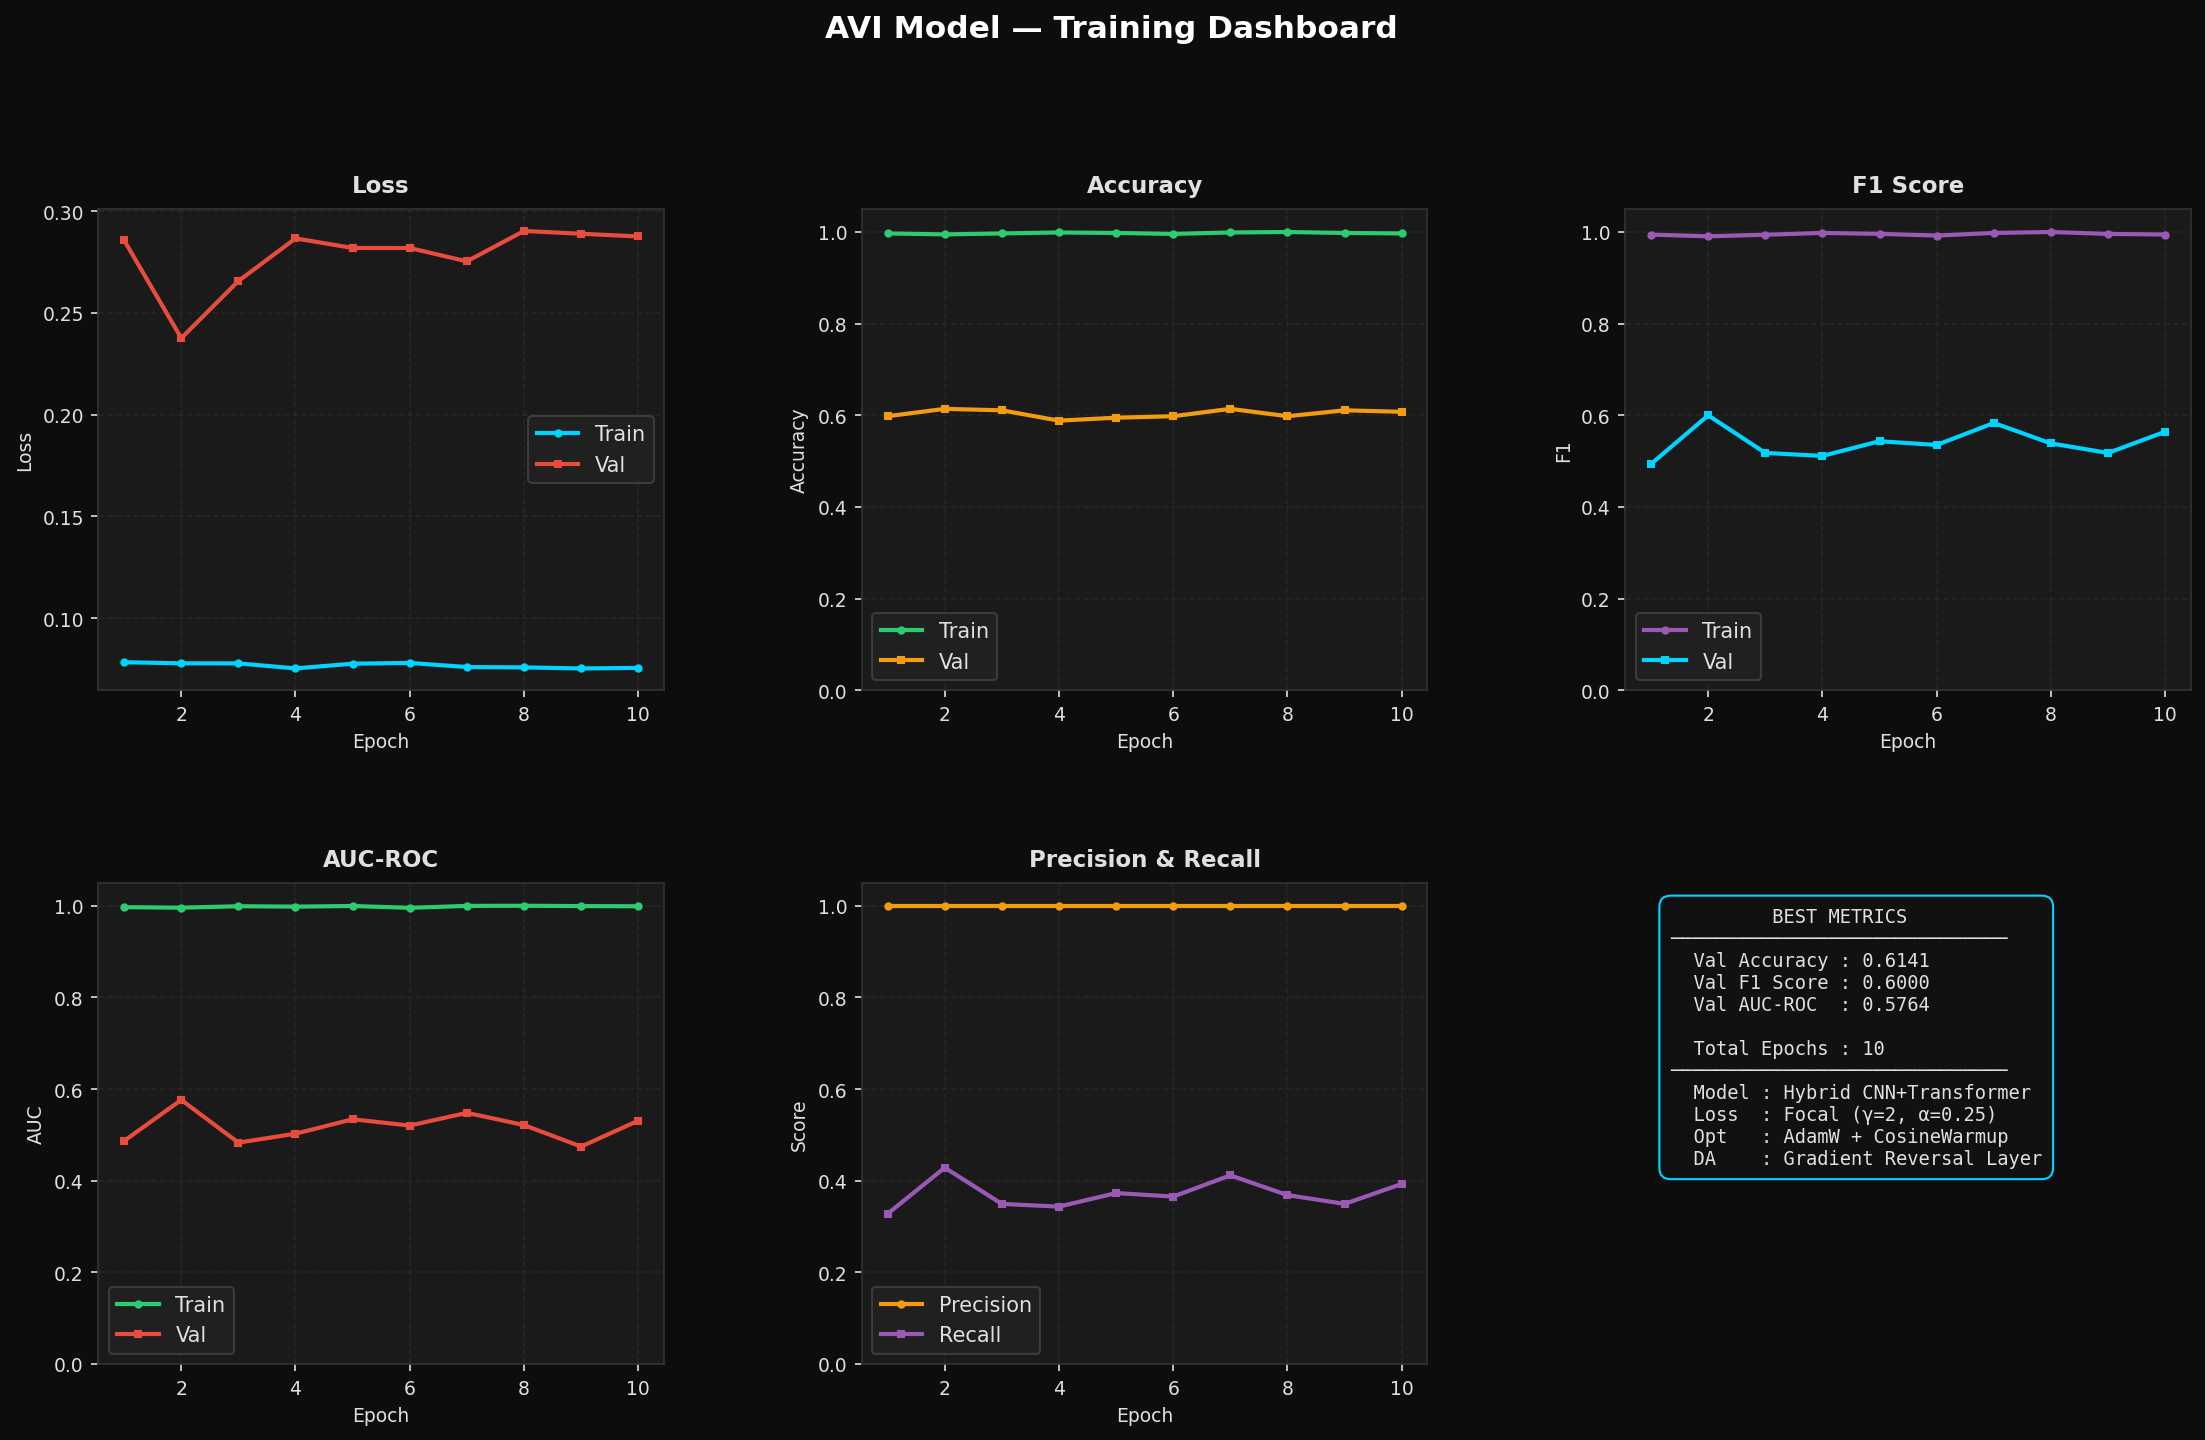

In [ ]:
DARK='#0d0d0d'; PANEL='#1a1a1a'; ACCENT='#00d4ff'
GREEN='#2ecc71'; RED='#e74c3c'; ORANGE='#f39c12'
PURPLE='#9b59b6'; TC='#e0e0e0'

def s(ax, title='', xl='', yl=''):
    ax.set_facecolor(PANEL); ax.tick_params(colors=TC, labelsize=9)
    ax.set_title(title, color=TC, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel(xl, color=TC, fontsize=9); ax.set_ylabel(yl, color=TC, fontsize=9)
    for sp in ax.spines.values(): sp.set_edgecolor('#333')
    ax.grid(True, color='#2a2a2a', lw=0.8, ls='--', alpha=0.7)

ep_x = list(range(1, len(history['train_loss'])+1))
fig  = plt.figure(figsize=(18, 10), facecolor=DARK)
gs   = gridspec.GridSpec(2, 3, hspace=0.4, wspace=0.35)

pairs = [
    (gs[0,0], 'Loss',              'Epoch', 'Loss',     'train_loss','val_loss',    ACCENT, RED),
    (gs[0,1], 'Accuracy',          'Epoch', 'Accuracy', 'train_acc', 'val_acc',     GREEN,  ORANGE),
    (gs[0,2], 'F1 Score',          'Epoch', 'F1',       'train_f1',  'val_f1',      PURPLE, ACCENT),
    (gs[1,0], 'AUC-ROC',           'Epoch', 'AUC',      'train_auc', 'val_auc',     GREEN,  RED),
    (gs[1,1], 'Precision & Recall','Epoch', 'Score',    'val_prec',  'val_rec',     ORANGE, PURPLE),
]
for (pos, title, xl, yl, k1, k2, c1, c2) in pairs:
    ax = fig.add_subplot(pos); s(ax, title, xl, yl)
    if k1 in history: ax.plot(ep_x, history[k1], color=c1, lw=2, label='Train' if 'train' in k1 else 'Precision', marker='o', ms=3)
    if k2 in history: ax.plot(ep_x, history[k2], color=c2, lw=2, label='Val' if 'val_' in k2 and 'prec' not in k2 and 'rec' not in k2 else ('Val' if 'loss' in k2 else 'Recall'), marker='s', ms=3)
    ax.legend(facecolor='#222', edgecolor='#444', labelcolor=TC)
    if 'loss' not in title.lower(): ax.set_ylim(0, 1.05)

ax6 = fig.add_subplot(gs[1,2]); ax6.set_facecolor(PANEL); ax6.axis('off')
summary = (
    f"{'BEST METRICS':^30}\n{'─'*30}\n"
    f"  Val Accuracy : {max(history['val_acc']):.4f}\n"
    f"  Val F1 Score : {max(history['val_f1']):.4f}\n"
    f"  Val AUC-ROC  : {max(history['val_auc']):.4f}\n\n"
    f"  Total Epochs : {len(ep_x)}\n{'─'*30}\n"
    f"  Model : Hybrid CNN+Transformer\n"
    f"  Loss  : Focal (γ=2, α=0.25)\n"
    f"  Opt   : AdamW + CosineWarmup\n"
    f"  DA    : Gradient Reversal Layer"
)
ax6.text(0.08, 0.95, summary, transform=ax6.transAxes, color=TC,
         fontsize=9, va='top', fontfamily='monospace',
         bbox=dict(facecolor='#111', edgecolor=ACCENT, boxstyle='round,pad=0.6'))

fig.suptitle('AVI Model — Training Dashboard', color='white', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('outputs/training_curves.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.close()
display(IPImage('outputs/training_curves.png'))

---
## CELL 8 — Confusion Matrix, ROC, PR Curves

              precision    recall  f1-score   support

        Good       0.49      1.00      0.66       120
   Defective       1.00      0.35      0.52       191

    accuracy                           0.60       311
   macro avg       0.75      0.68      0.59       311
weighted avg       0.80      0.60      0.57       311



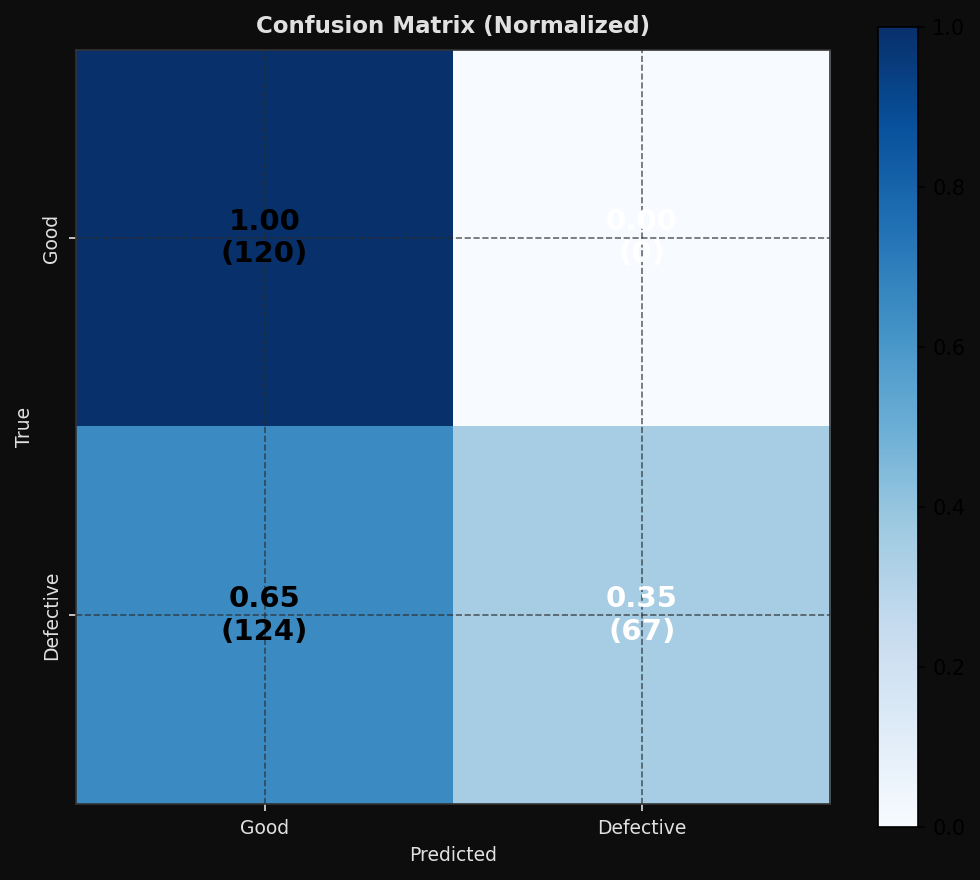

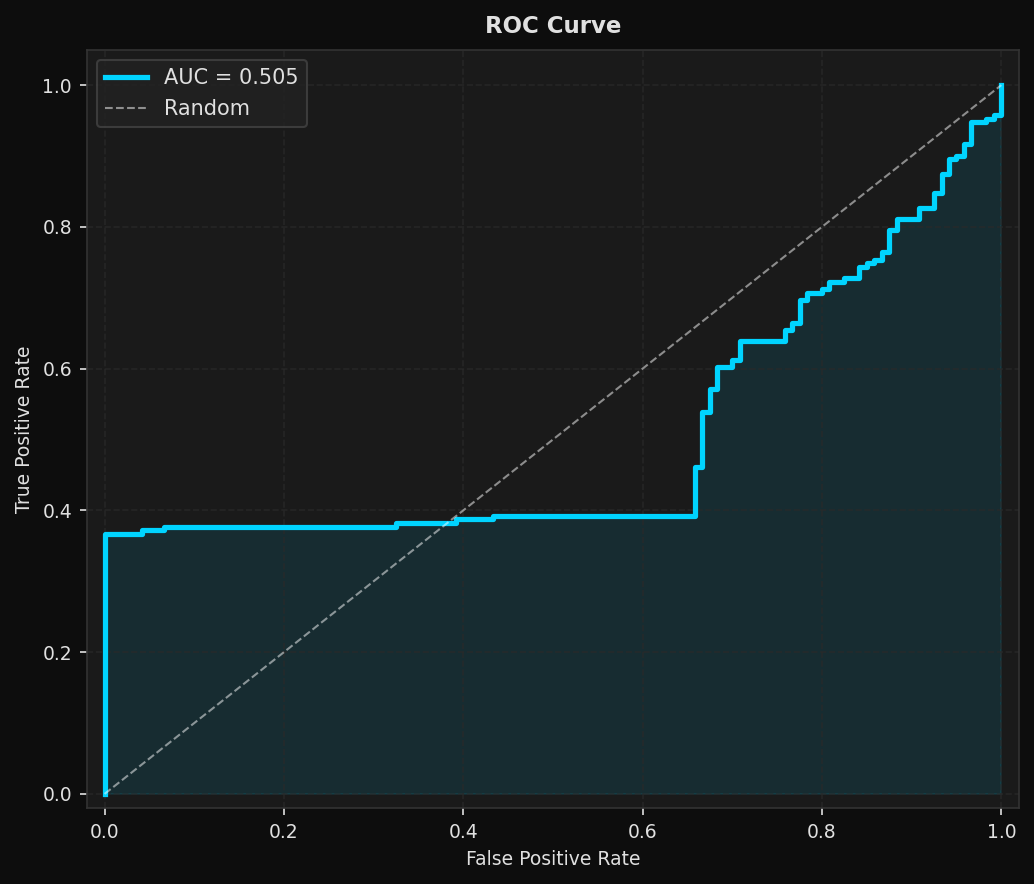

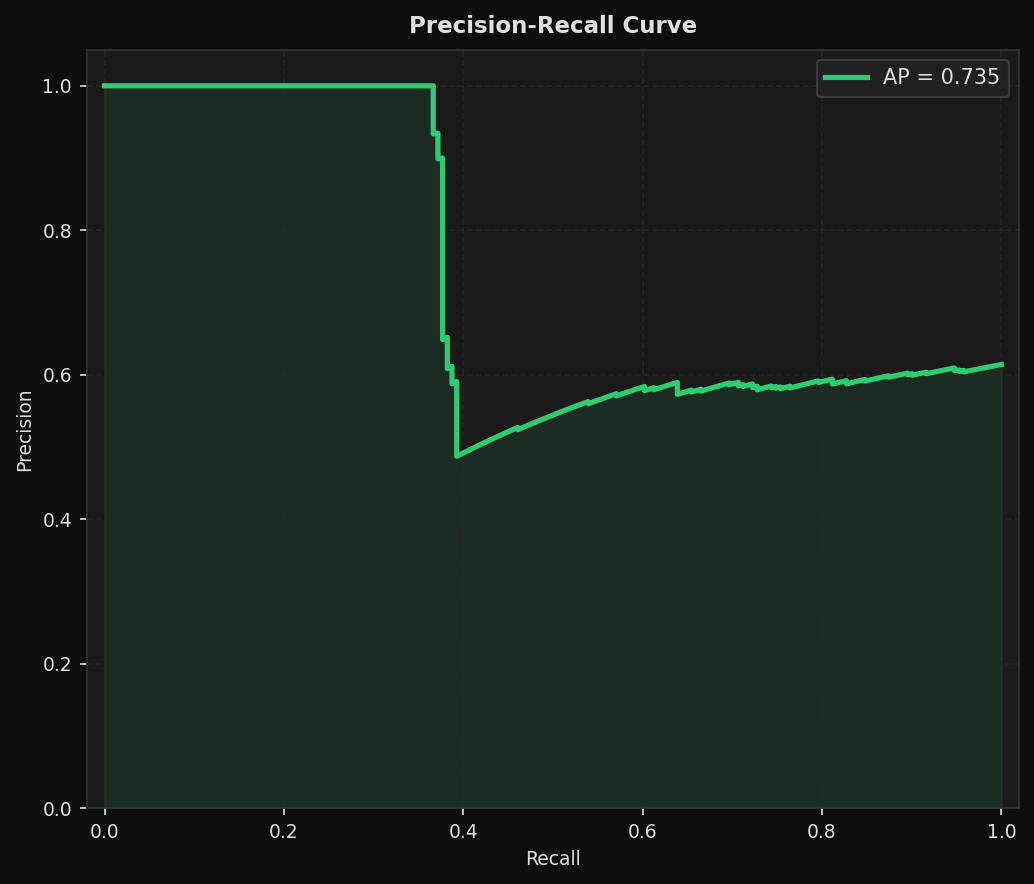

In [ ]:
# Get final val predictions
res = run_epoch(val_loader, train=False)
y_true, y_pred, y_prob = res['y_true'], res['y_pred'], res['y_prob']
CLASS_NAMES = ['Good', 'Defective']

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

# ── Confusion Matrix ────────────────────────────────────────────
cm   = confusion_matrix(y_true, y_pred)
cm_n = cm.astype('float') / cm.sum(axis=1, keepdims=True).clip(min=1)
fig, ax = plt.subplots(figsize=(7, 6), facecolor=DARK)
ax.set_facecolor(PANEL)
im = ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm_n[i,j]:.2f}\n({cm[i,j]})',
                ha='center', va='center', fontsize=14, fontweight='bold',
                color='black' if cm_n[i,j]>0.5 else 'white')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(CLASS_NAMES, color=TC, fontsize=12)
ax.set_yticklabels(CLASS_NAMES, color=TC, fontsize=12, rotation=90, va='center')
s(ax, 'Confusion Matrix (Normalized)', 'Predicted', 'True')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.close(); display(IPImage('outputs/confusion_matrix.png'))

# ── ROC Curve ────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_true, y_prob[:,1])
roc_auc     = auc(fpr, tpr)
fig, ax = plt.subplots(figsize=(7, 6), facecolor=DARK)
s(ax, 'ROC Curve', 'False Positive Rate', 'True Positive Rate')
ax.plot(fpr, tpr, color=ACCENT, lw=2.5, label=f'AUC = {roc_auc:.3f}')
ax.fill_between(fpr, tpr, alpha=0.1, color=ACCENT)
ax.plot([0,1],[0,1],'w--', lw=1, alpha=0.5, label='Random')
ax.set_xlim(-0.02,1.02); ax.set_ylim(-0.02,1.05)
ax.legend(facecolor='#222', edgecolor='#444', labelcolor=TC, fontsize=10)
plt.tight_layout()
plt.savefig('outputs/roc_curve.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.close(); display(IPImage('outputs/roc_curve.png'))

# ── PR Curve ─────────────────────────────────────────────────────
prec_c, rec_c, _ = precision_recall_curve(y_true, y_prob[:,1])
ap = average_precision_score(y_true, y_prob[:,1])
fig, ax = plt.subplots(figsize=(7, 6), facecolor=DARK)
s(ax, 'Precision-Recall Curve', 'Recall', 'Precision')
ax.plot(rec_c, prec_c, color=GREEN, lw=2.5, label=f'AP = {ap:.3f}')
ax.fill_between(rec_c, prec_c, alpha=0.1, color=GREEN)
ax.set_xlim(-0.02,1.02); ax.set_ylim(0.0,1.05)
ax.legend(facecolor='#222', edgecolor='#444', labelcolor=TC, fontsize=10)
plt.tight_layout()
plt.savefig('outputs/pr_curve.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.close(); display(IPImage('outputs/pr_curve.png'))

---
## CELL 9 — XAI: GradCAM + Attention Rollout

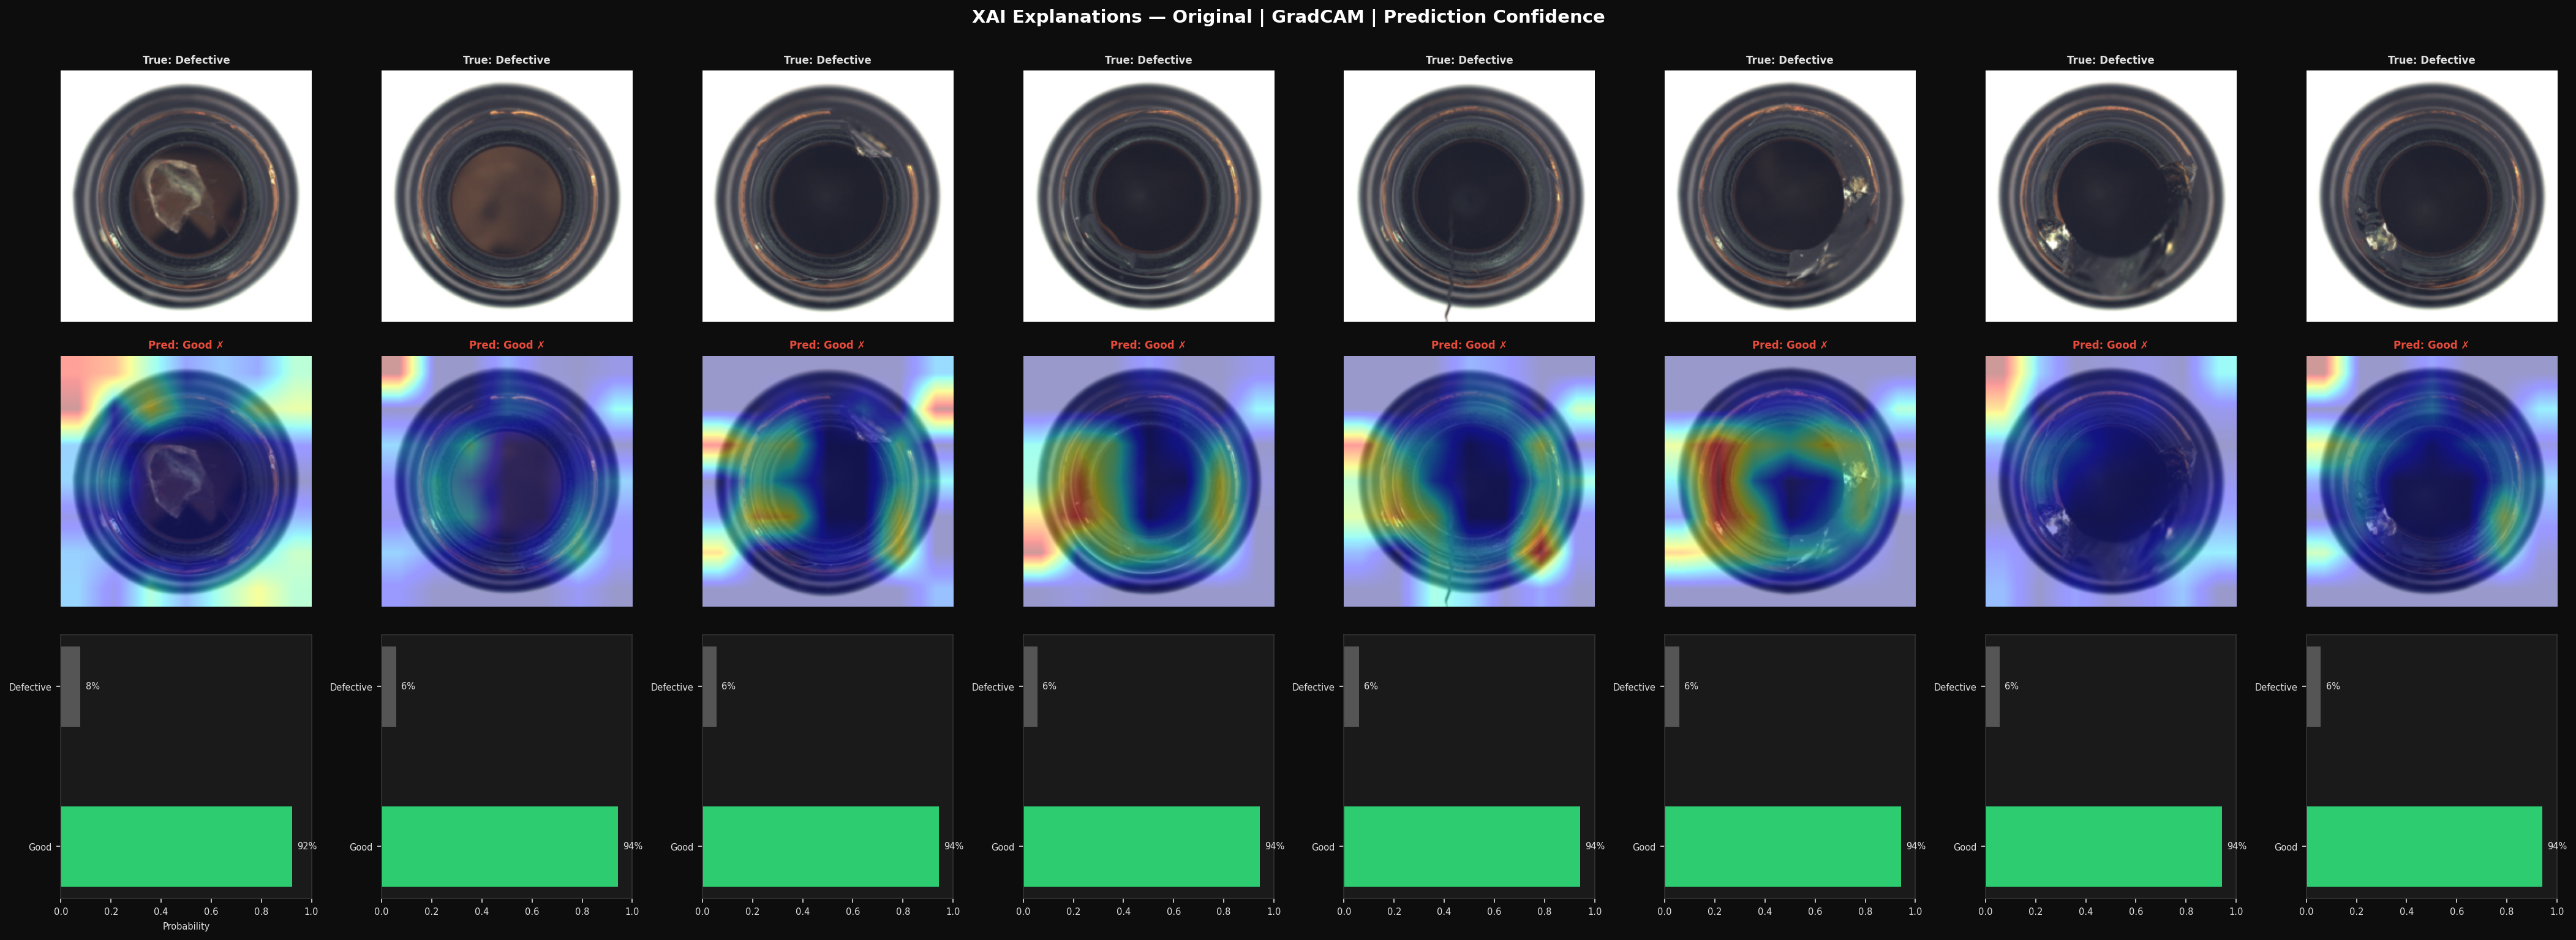

In [ ]:
DENORM_MEAN = torch.tensor([0.485, 0.456, 0.406])
DENORM_STD  = torch.tensor([0.229, 0.224, 0.225])

def denorm(t):
    img = t.cpu().clone()
    img = img * DENORM_STD[:,None,None] + DENORM_MEAN[:,None,None]
    return (img.clamp(0,1).permute(1,2,0).numpy() * 255).astype(np.uint8)

def gradcam(model, img_tensor, target_class=None):
    model.eval()
    gradients, activations = [], []

    # Hook on last conv layer of backbone
    target_layer = model.backbone.layer4[-1].conv3
    def fwd_hook(m, inp, out): activations.append(out.detach())
    def bwd_hook(m, gin, gout): gradients.append(gout[0].detach())
    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    x = img_tensor.unsqueeze(0).to(DEVICE).requires_grad_(True)
    logits, _ = model(x)
    tc = target_class if target_class is not None else logits.argmax(1).item()
    model.zero_grad()
    logits[0, tc].backward()

    h1.remove(); h2.remove()

    w   = gradients[0].mean(dim=[2,3], keepdim=True)
    cam = F.relu((w * activations[0]).sum(dim=1, keepdim=True))
    cam = cam.squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, tc, F.softmax(logits.detach().cpu(), dim=1)[0]

def overlay_cam(img_np, cam, alpha=0.4):
    h, w = img_np.shape[:2]
    cam_r = np.array(Image.fromarray((cam*255).astype(np.uint8)).resize((w,h), Image.BILINEAR)) / 255.0
    heat  = plt.cm.jet(cam_r)[:,:,:3]
    return np.clip((1-alpha)*img_np/255.0 + alpha*heat, 0, 1)

# ── Generate XAI grid ────────────────────────────────────────────
val_batch  = next(iter(val_loader))
imgs_xai   = val_batch['image']
labels_xai = val_batch['label']
N = min(8, len(imgs_xai))

fig, axes = plt.subplots(3, N, figsize=(N*3.5, 10), facecolor=DARK)
fig.suptitle('XAI Explanations — Original | GradCAM | Prediction Confidence',
             color='white', fontsize=14, fontweight='bold', y=1.01)

for i in range(N):
    img_np = denorm(imgs_xai[i])
    cam, pred_cls, probs = gradcam(model, imgs_xai[i])
    overlay = overlay_cam(img_np, cam)
    true_l  = labels_xai[i].item()
    correct = '✓' if pred_cls == true_l else '✗'
    c       = GREEN if correct == '✓' else RED

    # Row 0: original
    axes[0][i].imshow(img_np); axes[0][i].axis('off')
    axes[0][i].set_title(f'True: {CLASS_NAMES[true_l]}',
                         color=TC, fontsize=8, fontweight='bold')

    # Row 1: GradCAM
    axes[1][i].imshow(overlay); axes[1][i].axis('off')
    axes[1][i].set_title(f'Pred: {CLASS_NAMES[pred_cls]} {correct}',
                         color=c, fontsize=8, fontweight='bold')

    # Row 2: confidence bar
    ax = axes[2][i]
    ax.set_facecolor('#1a1a1a')
    colors = [GREEN if j==pred_cls else '#555' for j in range(2)]
    ax.barh(CLASS_NAMES, probs.numpy(), color=colors, height=0.5)
    ax.set_xlim(0, 1)
    for j, p in enumerate(probs.numpy()):
        ax.text(p+0.02, j, f'{p*100:.0f}%', va='center', color=TC, fontsize=7)
    ax.tick_params(colors=TC, labelsize=7)
    for sp in ax.spines.values(): sp.set_edgecolor('#333')
    if i == 0: ax.set_xlabel('Probability', color=TC, fontsize=7)

for ax_row in axes:
    for ax in ax_row: ax.set_facecolor('#1a1a1a')

plt.tight_layout(pad=0.5)
plt.savefig('outputs/xai/gradcam_grid.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.close()
display(IPImage('outputs/xai/gradcam_grid.png'))

---
## CELL 10 — Final Summary Report

In [ ]:
# Save full report
report_dict = {
    'model'     : 'Hybrid CNN + Vision Transformer',
    'datasets'  : ['MVTec AD (bottle + grid)', 'NEU-DET', 'Synthetic CAD'],
    'best_val_f1'     : float(best_f1),
    'best_val_acc'    : float(max(history['val_acc'])),
    'best_val_auc'    : float(max(history['val_auc'])),
    'total_epochs'    : len(history['train_loss']),
    'classification_report': classification_report(
        y_true, y_pred, target_names=CLASS_NAMES,
        output_dict=True, zero_division=0)
}
with open('outputs/final_report.json', 'w') as f:
    json.dump(report_dict, f, indent=2)

print('='*60)
print('  FINAL RESULTS — Hybrid CNN + Transformer AVI Model')
print('='*60)
print(f'  Datasets     : MVTec AD (Bottle+Grid) | NEU-DET | Synthetic')
print(f'  Architecture : ResNet-50 FPN + Multi-Head Transformer')
print(f'  Loss         : Focal Loss (α=0.25, γ=2.0)')
print(f'  Optimizer    : AdamW + CosineWarmup + Gradient Reversal DA')
print('─'*60)
print(f'  Best Val Accuracy  : {max(history["val_acc"]):.4f}')
print(f'  Best Val F1 Score  : {best_f1:.4f}')
print(f'  Best Val AUC-ROC   : {max(history["val_auc"]):.4f}')
print(f'  Best Val Precision : {max(history["val_prec"]):.4f}')
print(f'  Best Val Recall    : {max(history["val_rec"]):.4f}')
print('─'*60)
print(f'  Total Epochs Trained : {len(history["train_loss"])}')
print('─'*60)
print('  Output files:')
for f in sorted(os.listdir('outputs')):
    if f.endswith(('.png','.pth','.json')):
        print(f'    outputs/{f}')
for f in sorted(os.listdir('outputs/xai')):
    print(f'    outputs/xai/{f}')
print('='*60)

  FINAL RESULTS — Hybrid CNN + Transformer AVI Model
  Datasets     : MVTec AD (Bottle+Grid) | NEU-DET | Synthetic
  Architecture : ResNet-50 FPN + Multi-Head Transformer
  Loss         : Focal Loss (α=0.25, γ=2.0)
  Optimizer    : AdamW + CosineWarmup + Gradient Reversal DA
────────────────────────────────────────────────────────────
  Best Val Accuracy  : 0.6141
  Best Val F1 Score  : 0.6000
  Best Val AUC-ROC   : 0.5764
  Best Val Precision : 1.0000
  Best Val Recall    : 0.4286
────────────────────────────────────────────────────────────
  Total Epochs Trained : 10
────────────────────────────────────────────────────────────
  Output files:
    outputs/best_model.pth
    outputs/confusion_matrix.png
    outputs/final_report.json
    outputs/pr_curve.png
    outputs/roc_curve.png
    outputs/training_curves.png
    outputs/xai/gradcam_grid.png


---
## CELL 11 — Save everything to Google Drive

In [ ]:
import shutil
SAVE_PATH = f'{DRIVE_FOLDER}/AVI_Project_Results'
shutil.copytree('/content/outputs', SAVE_PATH, dirs_exist_ok=True)
print(f'✓ All results saved to Google Drive at:')
print(f'  {SAVE_PATH}/')
print()
print('Files saved:')
for root, dirs, files in os.walk(SAVE_PATH):
    for f in files:
        rel = os.path.join(root,f).replace(SAVE_PATH+'/', '')
        print(f'  {rel}')

✓ All results saved to Google Drive at:
  /content/drive/MyDrive/AVI_Project_Results/

Files saved:
  final_report.json
  confusion_matrix.png
  best_model.pth
  pr_curve.png
  training_curves.png
  roc_curve.png
  xai/gradcam_grid.png
